# Explore Results

In [3]:
import wheel
import pandas as pd
import numpy as np
import sklearn as skl
from mat4py import loadmat
import scipy.io
import csv
import struct
import os
import h5py
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps
from helpers.constants import *
from mne_bids import BIDSPath, read_raw_bids
from scipy.signal import butter, filtfilt
from mne.time_frequency import tfr_multitaper
import scipy
import seaborn as sb
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk
import tkinter as tk
import mne
from mne.viz import plot_alignment, snapshot_brain_montage
from mne.transforms import apply_trans
from mne.surface import read_surface
from helpers.constants import *
import warnings
import collections
from scipy import stats
from itertools import combinations
import seaborn as sns

In [4]:
%matplotlib inline
mne.viz.set_3d_backend('notebook')

Using notebook 3d backend.


In [5]:
"""
To use to notebook the following files are needed (So far files are only generated for subject 8 and 14 but more files can be created
using matlab scripts) 
-elecFinal table
-Python friendly converted tables (tables and strings are converted to cell arrays, every is converted to structs to avoid opaque issues)
-HDR, CurrState, Record, Trig-List raw, Trig-list sentence field
First module sets up the task data, second part visualizes electrodes, can comment everything above the h5py line if only neurological 
processing is needed
-Also change the variable Gen_Path to your local directory, Subject to the subject you want and Sub_Num to that subjects number
"""

'\nTo use to notebook the following files are needed (So far files are only generated for subject 8 and 14 but more files can be created\nusing matlab scripts) \n-elecFinal table\n-Python friendly converted tables (tables and strings are converted to cell arrays, every is converted to structs to avoid opaque issues)\n-HDR, CurrState, Record, Trig-List raw, Trig-list sentence field\nFirst module sets up the task data, second part visualizes electrodes, can comment everything above the h5py line if only neurological \nprocessing is needed\n-Also change the variable Gen_Path to your local directory, Subject to the subject you want and Sub_Num to that subjects number\n'

## Initializing Electrode Storage

In [6]:
elec_path = f"{EXPANSION_PATH}/Sub-Mat-Converted/elecFinal.mat" #This will stay static for every participant once its changed to the correct path                          

In [7]:
elec_raw = scipy.io.loadmat(elec_path, squeeze_me=True, simplify_cells = True, struct_as_record = False)

In [8]:
elec_frame = pd.DataFrame(elec_raw['elec_out'])

## Helper Functions

In [9]:
def find_files_with_pattern(start_dir, pattern):
    """
    Recursively finds all files matching a specific pattern within a directory.

    Args:
        start_dir (str): The root directory to start the search.
        pattern (str): The filename pattern to match (e.g., '*.txt', 'config_*.json').

    Returns:
        list: A list of absolute paths to the matching files.
    """
    matching_files = []
    # os.walk yields a tuple: (current_path, directories in current_path, files in current_path)
    for root, _, files in os.walk(start_dir):
        for filename in files:
            # Check if the filename matches the pattern
            if pattern in filename:
                # Construct the full path and add to the list
                full_path = os.path.join(root, filename)
                matching_files.append(full_path)
    return matching_files

In [10]:
def check_r2_tolerance(train_r2, test_r2, rel_threshold=25, abs_threshold=0.06):
    rel_diff = abs((test_r2 - train_r2) / train_r2) * 100
    abs_diff = abs(test_r2 - train_r2)
    return rel_diff <= rel_threshold or abs_diff <= abs_threshold

In [11]:
def pretty_print_df(name, df, max_rows=8):
    print(f"\n{'─'*12} {name} (n={len(df)}) {'─'*12}")
    if df.empty:
        print("No rows after filtering.")
    else:
        print(df.head(max_rows).to_string(index=False))
        if len(df) > max_rows:
            print(f"... ({len(df) - max_rows} more rows)")


In [12]:
def generate_all_electrodes(dict_conds, subject_data):
    """Generate structure with ALL electrodes (no filtering)"""
    all_electrodes = []
    for condition, sub_dict in dict_conds.items():
        for layer, frames_list in sub_dict.items():
            for frame in frames_list:
                bert_df = pd.DataFrame(frame['bert_results'])
                gpt_df = pd.DataFrame(frame['gpt_results'])
                t5_df = pd.DataFrame(frame['t5_results'])

                bert_merge = pd.merge(
                    bert_df,
                    subject_data,
                    left_index=True,
                    right_on='Elec_index',
                    how='inner'
                )
                gpt_merge = pd.merge(
                    gpt_df,
                    subject_data,
                    left_index=True,
                    right_on='Elec_index',
                    how='inner'
                )
                t5_merge = pd.merge(
                    t5_df,
                    subject_data,
                    left_index=True,
                    right_on='Elec_index',
                    how='inner'
                )
                
                bert_merge["condition"] = condition
                bert_merge["model"] = "BERT"
                bert_merge["layer"] = layer
                all_electrodes.append(bert_merge)
                
                gpt_merge["condition"] = condition
                gpt_merge["model"] = "GPT"
                gpt_merge["layer"] = layer
                all_electrodes.append(gpt_merge)
                
                t5_merge["condition"] = condition
                t5_merge["model"] = "T5"
                t5_merge["layer"] = layer
                all_electrodes.append(t5_merge)
            
            return all_electrodes

In [13]:
def generate_electrode_summary(dict_conds, subject_data):
    significant = []
    for condition,sub_dict in dict_conds.items():
        for layer, frames_list in sub_dict.items():
            print(f"LAYER: {layer}")
            for frame in frames_list:
                bert_df = pd.DataFrame(frame['bert_results'])
                gpt_df = pd.DataFrame(frame['gpt_results'])
                t5_df = pd.DataFrame(frame['t5_results'])

                bert_merge = pd.merge(
                bert_df,
                subject_data,
                left_index=True,   # Use df1's index
                right_on='Elec_index', # Use a specific column in df2
                how='inner'        # Specify the type of merge (e.g., 'inner', 'outer', 'left', 'right')
                )
                gpt_merge = pd.merge(
                    gpt_df,
                    subject_data,
                    left_index=True,   # Use df1's index
                    right_on='Elec_index', # Use a specific column in df2
                    how='inner'        # Specify the type of merge (e.g., 'inner', 'outer', 'left', 'right')
                )

                t5_merge = pd.merge(
                    t5_df,
                    subject_data,
                    left_index=True,   # Use df1's index
                    right_on='Elec_index', # Use a specific column in df2
                    how='inner'        # Specify the type of merge (e.g., 'inner', 'outer', 'left', 'right')
                )
                #Filter to only electrodes with baseline model explainability:
                bert_merge = bert_merge[bert_merge['test_R_2'] >= 0.1]
                gpt_merge = gpt_merge[gpt_merge['test_R_2'] >= 0.1]
                t5_merge = t5_merge[t5_merge['test_R_2'] >= 0.1]

                if len(bert_merge) > 0 or len(gpt_merge) > 0 or len(t5_merge) > 0:
                    print(" \n PROCESSING CONDITION: ", condition.upper()) #Only list significant conditions
                if len(bert_merge) > 0:
                    bert_merge["condition"] = condition
                    bert_merge["model"] = "BERT"
                    bert_merge["layer"] = layer
                    significant.append(bert_merge)
                    print()
                    pretty_print_df("BERT", bert_merge)
                if len(gpt_merge) > 0:
                    gpt_merge["condition"] = condition
                    gpt_merge["model"] = "GPT"
                    gpt_merge["layer"] = layer
                    print()
                    pretty_print_df("GPT", gpt_merge)
                    significant.append(gpt_merge)
                if len(t5_merge) > 0:
                    t5_merge["condition"] = condition
                    t5_merge["model"] = "T5"
                    t5_merge["layer"] = layer
                    print()
                    pretty_print_df("T5", t5_merge)
                    significant.append(t5_merge)
            return significant


In [14]:
def permutation_test_electrodes(further_filter_elecs, saved_elecs, n_permutations=10000):
    """
    Permutation test to check if filtered electrodes have significantly better
    R² values compared to all electrodes.
    
    Parameters:
    - further_filter_elecs: dict with filtered electrodes (train-test tolerance passed)
    - saved_elecs: dict with all significant electrodes
    - n_permutations: number of permutation iterations
    
    Returns:
    - results dictionary with p-values and effect sizes
    """
    results = {}
    
    for sub in further_filter_elecs.keys():
        print(f"\nRunning permutation test for Subject {sub}")
        
        # Get filtered and all electrodes
        filtered = further_filter_elecs[sub]
        all_elecs = saved_elecs[sub]
        
        n_filtered = len(filtered)
        n_all = len(all_elecs)
        
        if n_filtered == 0:
            print(f"No filtered electrodes for subject {sub}")
            continue
        
        # Extract test R² values
        filtered_r2 = np.array([elec['test_R_2'].values[0] for elec in filtered])
        all_r2 = np.array([elec['test_R_2'].values[0] for elec in all_elecs])
        
        # Observed test statistic (mean difference)
        observed_mean_filtered = np.mean(filtered_r2)
        observed_mean_all = np.mean(all_r2)
        observed_diff = observed_mean_filtered - observed_mean_all
        
        # Permutation test
        perm_diffs = []
        for _ in range(n_permutations):
            # Randomly sample n_filtered electrodes from all electrodes
            perm_sample = np.random.choice(all_r2, size=n_filtered, replace=False)
            perm_diff = np.mean(perm_sample) - observed_mean_all
            perm_diffs.append(perm_diff)
        
        perm_diffs = np.array(perm_diffs)
        
        # Calculate p-value (two-tailed)
        p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((n_filtered - 1) * np.var(filtered_r2) + 
                              (n_all - 1) * np.var(all_r2)) / (n_filtered + n_all - 2))
        cohens_d = observed_diff / pooled_std if pooled_std > 0 else 0
        
        results[sub] = {
            'n_filtered': n_filtered,
            'n_all': n_all,
            'mean_filtered_r2': observed_mean_filtered,
            'mean_all_r2': observed_mean_all,
            'mean_difference': observed_diff,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'significant': p_value < 0.05
        }
        
        print(f"  N filtered: {n_filtered}, N all: {n_all}")
        print(f"  Mean R² (filtered): {observed_mean_filtered:.4f}")
        print(f"  Mean R² (all): {observed_mean_all:.4f}")
        print(f"  Difference: {observed_diff:.4f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Cohen's d: {cohens_d:.4f}")
        print(f"  Significant: {p_value < 0.05}")
    
    return results

In [15]:

# Alternative: Test if train-test consistency is better
def permutation_test_consistency(further_filter_elecs, saved_elecs, n_permutations=10000):
    """
    Test if filtered electrodes have better train-test consistency
    """
    results = {}
    
    for sub in further_filter_elecs.keys():
        filtered = further_filter_elecs[sub]
        all_elecs = saved_elecs[sub]
        
        n_filtered = len(filtered)
        
        if n_filtered == 0:
            continue
        
        # Calculate train-test differences
        filtered_diffs = np.array([
            abs(elec['test_R_2'].values[0] - elec['train_R_2'].values[0]) 
            for elec in filtered
        ])
        all_diffs = np.array([
            abs(elec['test_R_2'].values[0] - elec['train_R_2'].values[0]) 
            for elec in all_elecs
        ])
        
        observed_mean_diff = np.mean(filtered_diffs) - np.mean(all_diffs)
        
        # Permutation
        perm_diffs = []
        for _ in range(n_permutations):
            perm_sample = np.random.choice(all_diffs, size=n_filtered, replace=False)
            perm_diffs.append(np.mean(perm_sample) - np.mean(all_diffs))
        
        p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_mean_diff))
        
        results[sub] = {
            'mean_consistency_filtered': np.mean(filtered_diffs),
            'mean_consistency_all': np.mean(all_diffs),
            'p_value': p_value,
            'significant': p_value < 0.05
        }
    
    return results

## Statistical Testing

In [16]:

def prepare_model_data(saved_elecs):
    """
    Extract and organize data by model and condition from saved_elecs structure
    
    Parameters:
    -----------
    saved_elecs : dict
        Dictionary with subjects as keys, list of dataframes as values
        Each dataframe has a 'model' column (BERT, GPT, T5) and 'condition' column
    
    Returns:
    --------
    model_data : dict
        Dictionary with keys 'BERT', 'GPT-2', 'T5', each containing combined dataframes
    condition_data : dict
        Dictionary with condition names as keys, containing model comparisons
    """
    
    
    # Initialize containers
    bert_list = []
    gpt_list = []
    t5_list = []
    
    print("\n" + "="*80)
    print("ORGANIZING DATA BY MODEL")
    print("="*80)
    
    # Collect all dataframes by model
    for sub, dfs in saved_elecs.items():
        print(f"\nProcessing Subject {sub}:")
        for i, df in enumerate(dfs):
            # Check if 'model' column exists
            if 'model' in df.columns:
                model = df['model'].iloc[0].upper()
                condition = df['condition'].iloc[0] if 'condition' in df.columns else 'unknown'
                n_rows = len(df)
                
                print(f"  DF {i}: Model={model}, Condition={condition}, Rows={n_rows}")
                
                if 'BERT' in model:
                    bert_list.append(df)
                elif 'GPT' in model:
                    gpt_list.append(df)
                elif 'T5' in model:
                    t5_list.append(df)
            else:
                # Fallback: infer from condition column
                condition = df['condition'].iloc[0].upper()
                n_rows = len(df)
                
                print(f"  DF {i}: No model column, Condition={condition}, Rows={n_rows}")
                
                if 'BERT' in condition:
                    bert_list.append(df)
                elif 'GPT' in condition:
                    gpt_list.append(df)
                elif 'T5' in condition:
                    t5_list.append(df)
    
    # Combine all data
    print("\n" + "="*80)
    print("COMBINING DATA BY MODEL")
    print("="*80)
    
    model_data = {}
    if bert_list:
        model_data['BERT'] = pd.concat(bert_list, ignore_index=True)
        print(f"  BERT: {len(bert_list)} dataframes combined -> {len(model_data['BERT'])} total rows")
        print(f"    Unique electrodes: {model_data['BERT']['electrode'].nunique()}")
        print(f"    Unique conditions: {model_data['BERT']['condition'].nunique()}")
    if gpt_list:
        model_data['GPT-2'] = pd.concat(gpt_list, ignore_index=True)
        print(f"  GPT-2: {len(gpt_list)} dataframes combined -> {len(model_data['GPT-2'])} total rows")
        print(f"    Unique electrodes: {model_data['GPT-2']['electrode'].nunique()}")
        print(f"    Unique conditions: {model_data['GPT-2']['condition'].nunique()}")
    if t5_list:
        model_data['T5'] = pd.concat(t5_list, ignore_index=True)
        print(f"  T5: {len(t5_list)} dataframes combined -> {len(model_data['T5'])} total rows")
        print(f"    Unique electrodes: {model_data['T5']['electrode'].nunique()}")
        print(f"    Unique conditions: {model_data['T5']['condition'].nunique()}")
    
    # Organize by condition
    print("\n" + "="*80)
    print("ORGANIZING DATA BY CONDITION")
    print("="*80)
    
    all_dfs = bert_list + gpt_list + t5_list
    condition_data = {}
    
    for df in all_dfs:
        cond = df['condition'].iloc[0]
        if cond not in condition_data:
            condition_data[cond] = {'BERT': [], 'GPT-2': [], 'T5': []}
        
        # Determine model
        if 'model' in df.columns:
            model = df['model'].iloc[0].upper()
            if 'BERT' in model:
                condition_data[cond]['BERT'].append(df)
            elif 'GPT' in model:
                condition_data[cond]['GPT-2'].append(df)
            elif 'T5' in model:
                condition_data[cond]['T5'].append(df)
        else:
            # Fallback
            if df in bert_list:
                condition_data[cond]['BERT'].append(df)
            elif df in gpt_list:
                condition_data[cond]['GPT-2'].append(df)
            elif df in t5_list:
                condition_data[cond]['T5'].append(df)
    
    # Print condition summary
    print(f"\nFound {len(condition_data)} conditions:")
    for cond, model_dict in condition_data.items():
        total_elecs = 0
        details = []
        for model, dfs in model_dict.items():
            if dfs:
                n_elecs = sum(len(df) for df in dfs)
                total_elecs += n_elecs
                details.append(f"{model}:{n_elecs}")
        print(f"  {cond}: {total_elecs} total electrode-model combinations ({', '.join(details)})")
    
    return model_data, condition_data

In [17]:
def compare_conditions_within_models(condition_data, use_r2=True):
    """
    Test if each model performs significantly better in specific conditions
    
    Parameters:
    -----------
    condition_data : dict
        Dictionary with condition names as keys, containing dict of model lists
    use_r2 : bool
        If True, use R², else use R
    """
    
    metric = 'test_R_2' if use_r2 else 'test_R'
    metric_name = 'R²' if use_r2 else 'R'
    
    print("\n" + "="*80)
    print(f"WITHIN-MODEL CONDITION COMPARISONS ({metric_name})")
    print("="*80)
    print("Testing if each model performs significantly better in certain conditions")
    print("="*80)
    
    # Organize data by model first
    model_condition_data = {'BERT': {}, 'GPT-2': {}, 'T5': {}}
    
    for cond, model_dict in condition_data.items():
        for model, dfs in model_dict.items():
            if len(dfs) > 0:
                combined = pd.concat(dfs, ignore_index=True)
                model_condition_data[model][cond] = combined[metric].values
    
    # Test each model separately
    for model in ['BERT', 'GPT-2', 'T5']:
        if len(model_condition_data[model]) == 0:
            continue
            
        print(f"\n{'='*80}")
        print(f"{model} - Condition Comparison")
        print('='*80)
        
        conditions = list(model_condition_data[model].keys())
        
        # Summary statistics
        print("\nCondition Summary:")
        print(f"{'Condition':<15} {'Mean':<10} {'Std':<10} {'Median':<10} {'N':<8}")
        print("-" * 60)
        for cond in conditions:
            data = model_condition_data[model][cond]
            print(f"{cond:<15} {np.mean(data):<10.4f} {np.std(data):<10.4f} "
                  f"{np.median(data):<10.4f} {len(data):<8}")
        
        # Pairwise comparisons between conditions
        if len(conditions) > 1:
            print("\nPairwise Comparisons (Mann-Whitney U test):")
            print(f"{'Comparison':<30} {'p-value':<12} {'Sig':<6} {'Effect Size (d)':<15} {'Mean Diff':<12}")
            print("-" * 90)
            
            for i, j in combinations(range(len(conditions)), 2):
                cond1, cond2 = conditions[i], conditions[j]
                data1 = model_condition_data[model][cond1]
                data2 = model_condition_data[model][cond2]
                
                # Mann-Whitney U test (unpaired)
                stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                
                # Effect size (Cohen's d)
                mean_diff = np.mean(data1) - np.mean(data2)
                pooled_std = np.sqrt((np.var(data1) + np.var(data2)) / 2)
                cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
                
                sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
                
                comparison = f"{cond1} vs {cond2}"
                print(f"{comparison:<30} {p_value:<12.4f} {sig:<6} {cohens_d:<15.4f} {mean_diff:<12.4f}")
        
        # If more than 2 conditions, do overall test
        if len(conditions) > 2:
            print("\nOverall Test (Kruskal-Wallis H-test):")
            condition_values = [model_condition_data[model][c] for c in conditions]
            h_stat, p_value = stats.kruskal(*condition_values)
            sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
            print(f"  H-statistic: {h_stat:.4f}")
            print(f"  p-value: {p_value:.4f} {sig}")
            
            if p_value < 0.05:
                # Find best performing condition
                means = {cond: np.mean(model_condition_data[model][cond]) for cond in conditions}
                best_cond = max(means, key=means.get)
                print(f"\n  Best performing condition: {best_cond} (Mean {metric_name} = {means[best_cond]:.4f})")

In [18]:

def visualize_within_model_conditions(condition_data, use_r2=True):
    """
    Visualize performance differences across conditions for each model
    """
    
    metric = 'test_R_2' if use_r2 else 'test_R'
    metric_name = 'R²' if use_r2 else 'R'
    
    # Prepare data
    plot_data = []
    for cond, model_dict in condition_data.items():
        for model, dfs in model_dict.items():
            if len(dfs) > 0:
                combined = pd.concat(dfs, ignore_index=True)
                for _, row in combined.iterrows():
                    plot_data.append({
                        'condition': cond,
                        'model': model,
                        metric: row[metric]
                    })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create separate plots for each model
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, model in enumerate(['BERT', 'GPT-2', 'T5']):
        model_data = plot_df[plot_df['model'] == model]
        
        if len(model_data) == 0:
            axes[idx].text(0.5, 0.5, f'No data for {model}', 
                          ha='center', va='center', transform=axes[idx].transAxes)
            continue
        
        # Box plot with swarm overlay
        sns.boxplot(data=model_data, x='condition', y=metric, ax=axes[idx], 
                   palette='Set2', width=0.6)
        sns.swarmplot(data=model_data, x='condition', y=metric, ax=axes[idx],
                     color='black', alpha=0.3, size=3)
        
        axes[idx].set_title(f'{model} - Performance by Condition', 
                           fontsize=14, fontweight='bold')
        axes[idx].set_ylabel(f'Test {metric_name}', fontsize=12)
        axes[idx].set_xlabel('Condition', fontsize=12)
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[idx].grid(True, alpha=0.3, axis='y')
        
        # Add mean line
        means = model_data.groupby('condition')[metric].mean()
        for i, cond in enumerate(model_data['condition'].unique()):
            axes[idx].hlines(means[cond], i-0.3, i+0.3, colors='red', 
                           linestyles='solid', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [19]:

def compare_model_performance_r2(model_data, use_r2=True):
    """
    Compare overall performance across models using R² or R
    
    Parameters:
    -----------
    model_data : dict
        Dictionary with model names as keys, dataframes as values
    use_r2 : bool
        If True, use R² (test_R_2), else use R (test_R)
    """
    
    metric = 'test_R_2' if use_r2 else 'test_R'
    metric_name = 'R²' if use_r2 else 'R'
    
    # Prepare combined data
    models_data = []
    for name, df in model_data.items():
        temp = pd.DataFrame()
        temp[metric] = df[metric]
        temp['test_MSE'] = df['test_MSE']
        temp['model'] = name
        models_data.append(temp)
    
    if len(models_data) == 0:
        print("No model data to compare!")
        return
    
    combined = pd.concat(models_data, ignore_index=True)
    
    # Create comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Test R² or R
    sns.boxplot(data=combined, x='model', y=metric, ax=axes[0], palette='Set2')
    sns.swarmplot(data=combined, x='model', y=metric, ax=axes[0], 
                  color='black', alpha=0.3, size=3)
    axes[0].set_title(f'Test {metric_name} by Model', fontsize=14, fontweight='bold')
    axes[0].set_ylabel(f'Test {metric_name}', fontsize=12)
    axes[0].set_xlabel('Model', fontsize=12)
    axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    
    # Test MSE
    sns.boxplot(data=combined, x='model', y='test_MSE', ax=axes[1], palette='Set2')
    sns.swarmplot(data=combined, x='model', y='test_MSE', ax=axes[1], 
                  color='black', alpha=0.3, size=3)
    axes[1].set_title('Test MSE by Model', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Test MSE', fontsize=12)
    axes[1].set_xlabel('Model', fontsize=12)
    axes[1].set_yscale("log")
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("="*80)
    print(f"MODEL PERFORMANCE SUMMARY ({metric_name})")
    print("="*80)
    for name, df in model_data.items():
        print(f"\n{name}:")
        print(f"  Mean Test {metric_name}: {df[metric].mean():.4f} ± {df[metric].std():.4f}")
        print(f"  Median Test {metric_name}: {df[metric].median():.4f}")
        print(f"  Mean Test MSE: {df['test_MSE'].mean():.4f} ± {df['test_MSE'].std():.4f}")
        print(f"  # Electrodes: {len(df)}")
        print(f"  # High performance ({metric_name} > 0.2): {(df[metric] > 0.2).sum()}")
    
    # Statistical comparison
    print("\n" + "="*80)
    print(f"PAIRWISE COMPARISONS (Wilcoxon signed-rank test on {metric_name})")
    print("="*80)
    
    model_names = list(model_data.keys())
    for i, j in combinations(range(len(model_names)), 2):
        name1, name2 = model_names[i], model_names[j]
        data1 = model_data[name1][metric].values
        data2 = model_data[name2][metric].values
        
        # Ensure equal length for paired test
        min_len = min(len(data1), len(data2))
        stat, p_value = stats.wilcoxon(data1[:min_len], data2[:min_len])
        
        # Effect size (rank-biserial correlation)
        diff = data1[:min_len] - data2[:min_len]
        r = (np.sum(diff > 0) - np.sum(diff < 0)) / min_len
        
        print(f"{name1} vs {name2}:")
        print(f"  p-value: {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")
        print(f"  Effect size (r): {r:.4f}")
        print(f"  Mean difference: {np.mean(diff):.4f}")

In [20]:

def compare_conditions(condition_data, use_r2=True):
    """
    Compare model performance across different conditions
    
    Parameters:
    -----------
    condition_data : dict
        Dictionary with condition names as keys, containing dict of model lists
    use_r2 : bool
        If True, use R², else use R
    """
    
    metric = 'test_R_2' if use_r2 else 'test_R'
    metric_name = 'R²' if use_r2 else 'R'
    
    # Prepare data for plotting
    plot_data = []
    for cond, model_dict in condition_data.items():
        for model, dfs in model_dict.items():
            if len(dfs) == 0:
                continue
                
            # Combine all dataframes for this model in this condition
            combined_df = pd.concat(dfs, ignore_index=True)
            
            for _, row in combined_df.iterrows():
                plot_data.append({
                    'condition': cond,
                    'model': model,
                    metric: row[metric],
                    'test_MSE': row['test_MSE']
                })
    
    if len(plot_data) == 0:
        print("No condition data to compare!")
        return
    
    plot_df = pd.DataFrame(plot_data)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Performance by condition
    sns.barplot(data=plot_df, x='condition', y=metric, hue='model', 
                ax=axes[0], palette='Set2', errorbar='se')
    axes[0].set_title(f'Model Performance by Condition ({metric_name})', 
                      fontsize=14, fontweight='bold')
    axes[0].set_ylabel(f'Mean Test {metric_name}', fontsize=12)
    axes[0].set_xlabel('Condition', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[0].legend(title='Model')
    
    # Count of electrodes by condition
    condition_counts = plot_df.groupby(['condition', 'model']).size().reset_index(name='count')
    sns.barplot(data=condition_counts, x='condition', y='count', hue='model',
                ax=axes[1], palette='Set2')
    axes[1].set_title('Number of High-Preforming Electrodes (r^2 > 0.1) by Condition', 
                      fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Number of Electrodes', fontsize=12)
    axes[1].set_xlabel('Condition', fontsize=12)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Model')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical tests per condition
    print("\n" + "="*80)
    print(f"CONDITION-SPECIFIC COMPARISONS ({metric_name})")
    print("="*80)
    
    unique_conditions = plot_df['condition'].unique()
    
    for cond in unique_conditions:
        print(f"\n{cond.upper()}:")
        cond_subset = plot_df[plot_df['condition'] == cond]
        
        models_in_cond = cond_subset['model'].unique()
        
        # Print summary stats
        for model in models_in_cond:
            model_data = cond_subset[cond_subset['model'] == model][metric]
            print(f"  {model}: Mean {metric_name} = {model_data.mean():.4f} ± {model_data.std():.4f} (n={len(model_data)})")
        
        # Pairwise tests
        if len(models_in_cond) > 1:
            print(f"\n  Pairwise comparisons:")
            for i, j in combinations(range(len(models_in_cond)), 2):
                m1, m2 = models_in_cond[i], models_in_cond[j]
                data1 = cond_subset[cond_subset['model'] == m1][metric].values
                data2 = cond_subset[cond_subset['model'] == m2][metric].values
                
                # Use Mann-Whitney U test (unpaired)
                stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                
                # Effect size (Cohen's d)
                mean_diff = np.mean(data1) - np.mean(data2)
                pooled_std = np.sqrt((np.var(data1) + np.var(data2)) / 2)
                cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
                
                sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
                print(f"    {m1} vs {m2}: p={p_value:.4f} {sig}, d={cohens_d:.4f}")


In [21]:
def compare_r_vs_r2(model_data):
    """
    Compare whether R or R² is more powerful for detecting differences
    """
    
    print("\n" + "="*80)
    print("R vs R² STATISTICAL POWER COMPARISON")
    print("="*80)
    
    model_names = list(model_data.keys())
    
    print("\nEffect sizes and p-values using R:")
    print("-" * 80)
    
    for i, j in combinations(range(len(model_names)), 2):
        name1, name2 = model_names[i], model_names[j]
        data1_r = model_data[name1]['test_R'].values
        data2_r = model_data[name2]['test_R'].values
        
        min_len = min(len(data1_r), len(data2_r))
        stat_r, p_r = stats.wilcoxon(data1_r[:min_len], data2_r[:min_len])
        
        # Effect size
        diff_r = data1_r[:min_len] - data2_r[:min_len]
        r_effect = (np.sum(diff_r > 0) - np.sum(diff_r < 0)) / min_len
        
        print(f"{name1} vs {name2}:")
        print(f"  R:  p={p_r:.6f}, effect size={r_effect:.4f}, mean diff={np.mean(diff_r):.4f}")
    
    print("\nEffect sizes and p-values using R²:")
    print("-" * 80)
    
    for i, j in combinations(range(len(model_names)), 2):
        name1, name2 = model_names[i], model_names[j]
        data1_r2 = model_data[name1]['test_R_2'].values
        data2_r2 = model_data[name2]['test_R_2'].values
        
        min_len = min(len(data1_r2), len(data2_r2))
        stat_r2, p_r2 = stats.wilcoxon(data1_r2[:min_len], data2_r2[:min_len])
        
        # Effect size
        diff_r2 = data1_r2[:min_len] - data2_r2[:min_len]
        r2_effect = (np.sum(diff_r2 > 0) - np.sum(diff_r2 < 0)) / min_len
        
        print(f"{name1} vs {name2}:")
        print(f"  R²: p={p_r2:.6f}, effect size={r2_effect:.4f}, mean diff={np.mean(diff_r2):.4f}")


In [22]:
def run_comprehensive_analysis(saved_elecs):
    """
    Run all analyses on the saved_elecs data structure
    
    Parameters:
    -----------
    saved_elecs : dict
        Your saved_elecs dictionary from the pipeline
    """
    
    print("\n" + "="*80)
    print("PREPARING DATA")
    print("="*80)
    
    model_data, condition_data = prepare_model_data(saved_elecs)
    
    print(f"\nFound {len(model_data)} models:")
    for model, df in model_data.items():
        print(f"  {model}: {len(df)} electrodes")
    
    print(f"\nFound {len(condition_data)} conditions:")
    for cond, dfs in condition_data.items():
        n_elecs = sum(len(df) for df in dfs)
        print(f"  {cond}: {n_elecs} electrodes")
    
    # Run analyses
    print("\n" + "="*80)
    print("1. OVERALL MODEL PERFORMANCE (using R²)")
    print("="*80)
    compare_model_performance_r2(model_data, use_r2=True)
    
    print("\n" + "="*80)
    print("2. CONDITION-SPECIFIC ANALYSIS")
    print("="*80)
    compare_conditions(condition_data, use_r2=True)
    
    print("\n" + "="*80)
    print("3. WITHIN-MODEL CONDITION COMPARISONS")
    print("="*80)
    compare_conditions_within_models(condition_data, use_r2=True)
    visualize_within_model_conditions(condition_data, use_r2=True)
    
    print("\n" + "="*80)
    print("4. R vs R² POWER COMPARISON")
    print("="*80)
    compare_r_vs_r2(model_data)
    
    return model_data, condition_data

## Memory Management Fixes

In [23]:
if 'brain' in locals(): #helps avoid memory issues with brain model
    brain.close() 

In [24]:
plt.close('all')

In [25]:
warnings.filterwarnings('ignore')

## Subject Generation Loops

In [ ]:
elec_counter = 0
saved_elecs = {}  # High-performing only
all_elecs = {}    # ALL electrodes
subjects_run = [1,8,5,9,4,13,15]

for sub in subjects_run:
    Subject = f"S{sub}"
    print(f"\n RUNNING SUBJECT {Subject}")
    Sub_num = sub
    Gen_Path = f"{EXPANSION_PATH}/Sub-Mat-Converted/{Subject}/"
    record_direc = DIRECTORYS[sub]
    subjects_dir = EXPANSION_PATH 

    # Filter Subject Data
    subject_elecs = elec_frame[(elec_frame['subjectNum'] == Sub_num) & 
                          (elec_frame['isRejectFSL'] != 1) & 
                          (elec_frame['isRejectManual'] != 1) & 
                          (elec_frame['isRejectFSL'] != 1)]
    
    subject_elecs["elecNum"] = subject_elecs["elecNum"].astype(int)
    subject_elecs["Elec_index"] = subject_elecs["elecNum"] - 1

    # Finding Subject Regression Results files
    sub_files = find_files_with_pattern("results_regress_layers", f"S{sub}")
    print(sub_files)

    # Creating loop_able dictionary
    keys_list = ["overall", "GS", "GNS","NGNS","a","v"]
    conds_dict = dict.fromkeys(keys_list, {})

    for file_path in sub_files:
        data = pd.read_pickle(file_path)
        parts = file_path.split('/')
        top_level_condition = parts[1]
        layer_cond = parts[2]
        #Create key
        if not layer_cond in conds_dict[top_level_condition]:
            conds_dict[top_level_condition][layer_cond] = [data]
        else:
            conds_dict[top_level_condition][layer_cond].append(data)    

    
    # Generate BOTH filtered and unfiltered electrode sets
    all_elecs[sub] = generate_all_electrodes(conds_dict, subject_elecs)
    saved_elecs[sub] = generate_electrode_summary(conds_dict, subject_elecs)
    elec_counter += len(saved_elecs[sub]) 

print(f"Found {elec_counter} high-performing electrodes")
print(f"Total electrodes (all): {sum(len(all_elecs[sub]) for sub in all_elecs)}")



In [ ]:
print("\n" + "="*80)
print("ANALYSIS ON ALL ELECTRODES")
print("="*80)

model_data_filtered, condition_data_filtered = run_comprehensive_analysis(all_elecs)


ANALYSIS ON ALL ELECTRODES

PREPARING DATA

ORGANIZING DATA BY MODEL

Processing Subject 1:
  DF 0: Model=BERT, Condition=overall, Rows=110
  DF 1: Model=GPT, Condition=overall, Rows=110
  DF 2: Model=T5, Condition=overall, Rows=110
  DF 3: Model=BERT, Condition=overall, Rows=110
  DF 4: Model=GPT, Condition=overall, Rows=110
  DF 5: Model=T5, Condition=overall, Rows=110
  DF 6: Model=BERT, Condition=overall, Rows=110
  DF 7: Model=GPT, Condition=overall, Rows=110
  DF 8: Model=T5, Condition=overall, Rows=110
  DF 9: Model=BERT, Condition=overall, Rows=110
  DF 10: Model=GPT, Condition=overall, Rows=110
  DF 11: Model=T5, Condition=overall, Rows=110
  DF 12: Model=BERT, Condition=overall, Rows=110
  DF 13: Model=GPT, Condition=overall, Rows=110
  DF 14: Model=T5, Condition=overall, Rows=110
  DF 15: Model=BERT, Condition=overall, Rows=110
  DF 16: Model=GPT, Condition=overall, Rows=110
  DF 17: Model=T5, Condition=overall, Rows=110
  DF 18: Model=BERT, Condition=overall, Rows=110
  DF

KeyboardInterrupt: 

## Imposing Tolerance of R^2 value To filer down electrodes

In [132]:
further_filter_elecs = collections.defaultdict(list)
for sub, data in saved_elecs.items():
    for elec in data:
        train_R_2 = float(elec["train_R_2"].iloc[0])
        test_R_2 = float(elec["test_R_2"].iloc[0])
        
        if check_r2_tolerance(train_R_2, test_R_2, ):
            further_filter_elecs[sub].append(elec)

In [133]:
counter = 0
for sub,data in further_filter_elecs.items():
    print(f"SUBJECT DATA S{sub}")
    for elec in data:
        print(elec.columns)
        counter+=1
        print(elec)
print(f"{counter} Electrodes Remaining")

SUBJECT DATA S1
Index(['electrode', 'best_alpha', 'train_MSE', 'test_MSE', 'train_R', 'test_R',
       'train_R_2', 'test_R_2', 'subjectNum', 'elecNum', 'isRejectManual',
       'parcLabel', 'ctxParc', 'wmParc', 'isRejectFSL_2wm', 'isRejectFSL',
       'isWM', 'unknown_wmParc', 'groupLabels', 'isLeft', 'groupAvgCoords',
       'Elec_index', 'condition', 'model'],
      dtype='object')
       electrode  best_alpha  train_MSE  test_MSE   train_R    test_R  \
12  electrode_12       100.0   0.094144  0.048984  0.449937  0.361191   

    train_R_2  test_R_2  subjectNum  elecNum  ...  isRejectFSL_2wm  \
12    0.12378    0.1054           1       13  ...                0   

   isRejectFSL isWM unknown_wmParc   groupLabels  isLeft  \
12           0    1              0  LAI13 s1 e13       1   

                                       groupAvgCoords  Elec_index condition  \
12  [-40.86806661504363, 29.39356787918851, 23.507...          12        GS   

    model  
12   BERT  

[1 rows x 24 column

## Permutation Test

In [134]:
# Run the tests
results_r2 = permutation_test_electrodes(further_filter_elecs, saved_elecs)
results_consistency = permutation_test_consistency(further_filter_elecs, saved_elecs)

# Summary across subjects
print("\n=== OVERALL SUMMARY ===")
all_p_values = [r['p_value'] for r in results_r2.values()]
print(f"Subjects with p < 0.05: {sum([r['significant'] for r in results_r2.values()])}/{len(results_r2)}")
print(f"Mean p-value: {np.mean(all_p_values):.4f}")


Running permutation test for Subject 1
  N filtered: 4, N all: 7
  Mean R² (filtered): 0.1499
  Mean R² (all): 0.1604
  Difference: -0.0105
  P-value: 0.6032
  Cohen's d: -0.1867
  Significant: False

Running permutation test for Subject 8
  N filtered: 4, N all: 5
  Mean R² (filtered): 0.1238
  Mean R² (all): 0.1216
  Difference: 0.0022
  P-value: 0.7978
  Cohen's d: 0.1397
  Significant: False

Running permutation test for Subject 12
  N filtered: 4, N all: 6
  Mean R² (filtered): 0.1243
  Mean R² (all): 0.1325
  Difference: -0.0082
  P-value: 0.4651
  Cohen's d: -0.3517
  Significant: False

=== OVERALL SUMMARY ===
Subjects with p < 0.05: 0/3
Mean p-value: 0.6220


In [137]:
saved_elecs[1][0]

,electrode,best_alpha,train_MSE,test_MSE,train_R,test_R,train_R_2,test_R_2,subjectNum,elecNum,...,isRejectFSL_2wm,isRejectFSL,isWM,unknown_wmParc,groupLabels,isLeft,groupAvgCoords,Elec_index,condition,model
12,electrode_12,100.0,0.094144,0.048984,0.449937,0.361191,0.12378,0.1054,1,13,...,0,0,1,0,LAI13 s1 e13,1,"[-40.86806661504363, 29.39356787918851, 23.507...",12,GS,BERT



PREPARING DATA
  BERT: 11 electrodes
  GPT-2: 25 electrodes
  T5: 2 electrodes

Found 3 models:
  BERT: 11 electrodes
  GPT-2: 25 electrodes
  T5: 2 electrodes

Found 3 conditions:
  GS: 11 electrodes
  GNS: 11 electrodes
  NGNS: 11 electrodes

1. OVERALL MODEL PERFORMANCE (using R²)


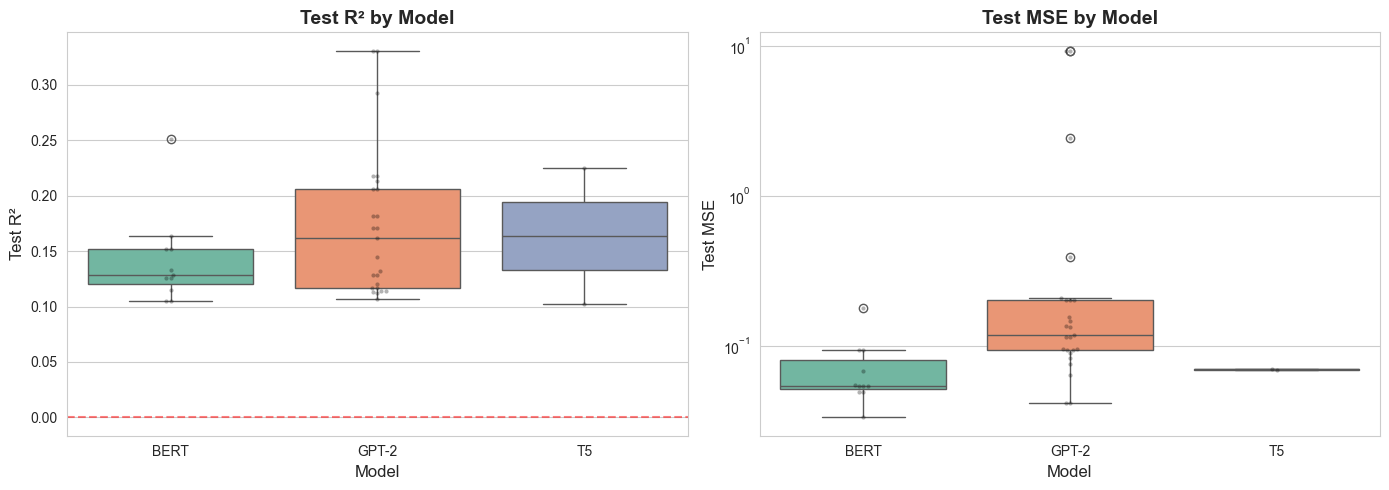

MODEL PERFORMANCE SUMMARY (R²)

BERT:
  Mean Test R²: 0.1416 ± 0.0410
  Median Test R²: 0.1287
  Mean Test MSE: 0.0709 ± 0.0400
  # Electrodes: 11
  # High performance (R² > 0.2): 1

GPT-2:
  Mean Test R²: 0.1731 ± 0.0665
  Median Test R²: 0.1617
  Mean Test MSE: 0.9582 ± 2.5569
  # Electrodes: 25
  # High performance (R² > 0.2): 8

T5:
  Mean Test R²: 0.1639 ± 0.0866
  Median Test R²: 0.1639
  Mean Test MSE: 0.0694 ± 0.0009
  # Electrodes: 2
  # High performance (R² > 0.2): 1

PAIRWISE COMPARISONS (Wilcoxon signed-rank test on R²)
BERT vs GPT-2:
  p-value: 0.2402 ns
  Effect size (r): -0.4545
  Mean difference: -0.0305
BERT vs T5:
  p-value: 1.0000 ns
  Effect size (r): 0.0000
  Mean difference: 0.0144
GPT-2 vs T5:
  p-value: 1.0000 ns
  Effect size (r): 0.0000
  Mean difference: -0.0028

2. CONDITION-SPECIFIC ANALYSIS


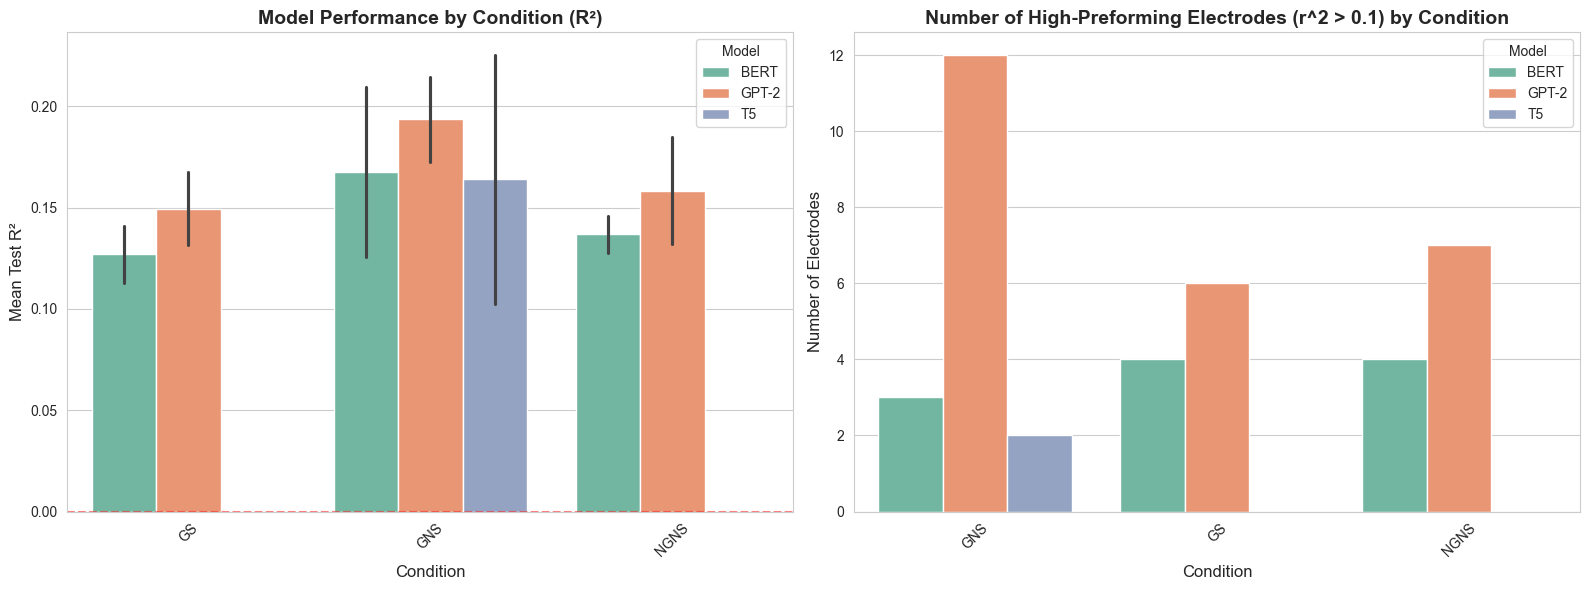


CONDITION-SPECIFIC COMPARISONS (R²)

GS:
  BERT: Mean R² = 0.1269 ± 0.0279 (n=4)
  GPT-2: Mean R² = 0.1495 ± 0.0439 (n=6)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.4514 ns, d=-0.6807

GNS:
  BERT: Mean R² = 0.1675 ± 0.0724 (n=3)
  GPT-2: Mean R² = 0.1935 ± 0.0723 (n=12)
  T5: Mean R² = 0.1639 ± 0.0866 (n=2)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.6125 ns, d=-0.4033
    BERT vs T5: p=0.7671 ns, d=0.0600
    GPT-2 vs T5: p=0.7837 ns, d=0.4525

NGNS:
  BERT: Mean R² = 0.1368 ± 0.0184 (n=4)
  GPT-2: Mean R² = 0.1584 ± 0.0697 (n=7)

  Pairwise comparisons:
    BERT vs GPT-2: p=0.7753 ns, d=-0.4582

3. WITHIN-MODEL CONDITION COMPARISONS

WITHIN-MODEL CONDITION COMPARISONS (R²)
Testing if each model performs significantly better in certain conditions

BERT - Condition Comparison

Condition Summary:
Condition       Mean       Std        Median     N       
------------------------------------------------------------
GS              0.1269     0.0241     0.1192     4       
GNS  

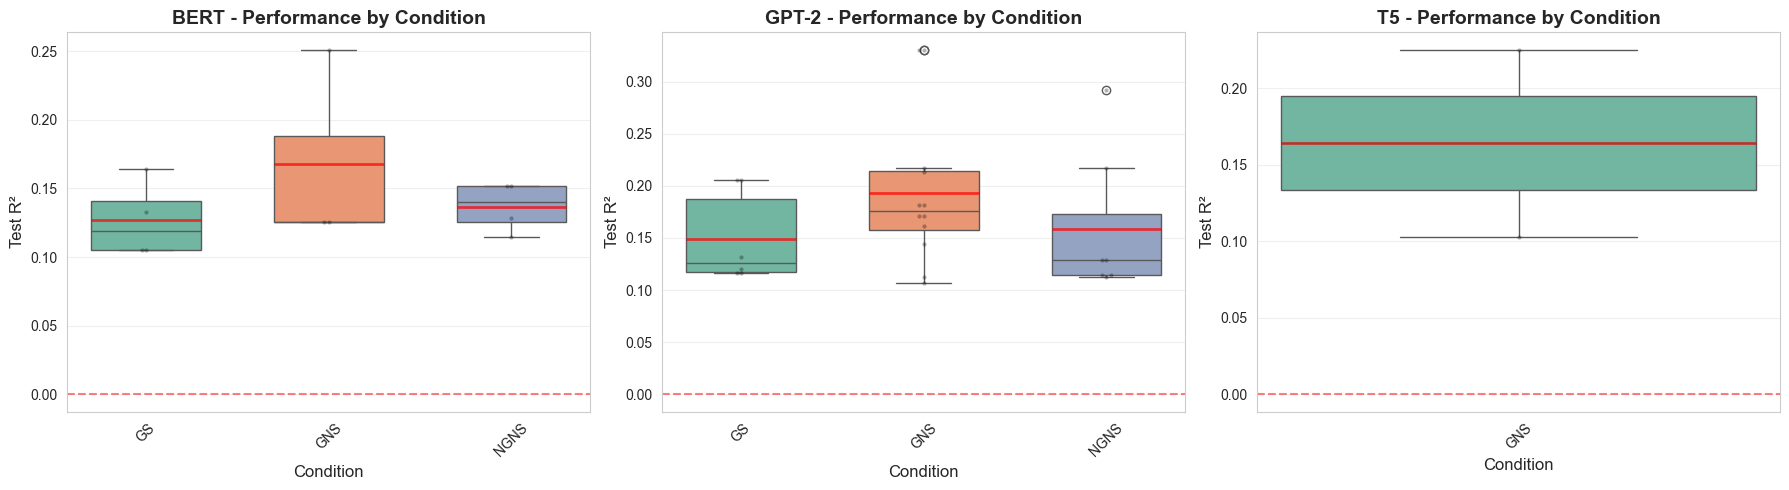


4. R vs R² POWER COMPARISON

R vs R² STATISTICAL POWER COMPARISON

Effect sizes and p-values using R:
--------------------------------------------------------------------------------
BERT vs GPT-2:
  R:  p=0.764648, effect size=0.0909, mean diff=-0.0324
BERT vs T5:
  R:  p=1.000000, effect size=0.0000, mean diff=-0.0147
GPT-2 vs T5:
  R:  p=1.000000, effect size=0.0000, mean diff=-0.0144

Effect sizes and p-values using R²:
--------------------------------------------------------------------------------
BERT vs GPT-2:
  R²: p=0.240234, effect size=-0.4545, mean diff=-0.0305
BERT vs T5:
  R²: p=1.000000, effect size=0.0000, mean diff=0.0144
GPT-2 vs T5:
  R²: p=1.000000, effect size=0.0000, mean diff=-0.0028


In [ ]:
print("\n" + "="*80)
print("ANALYSIS ON HIGH-PERFORMING ELECTRODES ONLY (R² >= 0.1)")
print("="*80)
model_data, condition_data = run_comprehensive_analysis(saved_elecs)


### Filter to Good Electrodes

## Brain Plotting


In [85]:
subject_data["elecNum"] = subject_data["elecNum"].astype(int)
#superior temporal sulcus

#inferior temporal sulcus

/var/folders/0t/606k27ps1dl99nq5_thgf5mm0000gn/T/ipykernel_1929/2848400210.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subject_data["elecNum"] = subject_data["elecNum"].astype(int)


In [80]:
subject_data[(subject_data["elecNum"] == 47) | (subject_data["elecNum"] == 157) | (subject_data["elecNum"] == 27) | (subject_data["elecNum"] == 83) | (subject_data["elecNum"] == 102)
             | (subject_data["elecNum"] == 82) | (subject_data["elecNum"] == 60) | (subject_data["elecNum"] == 8) | (subject_data["elecNum"] == 46) | (subject_data["elecNum"] == 162)]

,subjectNum,elecNum,isRejectManual,parcLabel,ctxParc,wmParc,isRejectFSL_2wm,isRejectFSL,isWM,unknown_wmParc,groupLabels,isLeft,groupAvgCoords,electNum
1071,12,8,0,S_temporal_sup,ctx_lh_S_temporal_sup,S_temporal_sup,0,0,0,0,A8 s12 e8,1,"[-57.78034605398017, -7.737478772702019, -28.0...",8
1086,12,27,0,S_temporal_inf,Left-Cerebral-White-Matter,S_temporal_inf,0,0,1,0,Ci7 s12 e27,1,"[-65.06336379718016, -44.361677603302, -16.274...",27


In [81]:
elecnums = [47, 157, 27, 83, 102, 82, 60, 8, 46, 162]
filtered = subject_data[subject_data["elecNum"].isin(elecnums)]


In [82]:
filtered

,subjectNum,elecNum,isRejectManual,parcLabel,ctxParc,wmParc,isRejectFSL_2wm,isRejectFSL,isWM,unknown_wmParc,groupLabels,isLeft,groupAvgCoords,electNum
1071,12,8,0,S_temporal_sup,ctx_lh_S_temporal_sup,S_temporal_sup,0,0,0,0,A8 s12 e8,1,"[-57.78034605398017, -7.737478772702019, -28.0...",8
1086,12,27,0,S_temporal_inf,Left-Cerebral-White-Matter,S_temporal_inf,0,0,1,0,Ci7 s12 e27,1,"[-65.06336379718016, -44.361677603302, -16.274...",27


In [20]:
#Create a dictionary for electode positions, key <- electode number, value <- coordinates 
elec_pos = []
for idx, row in subject_data.iterrows():
    curr_dict = {}
    coords = list(row['groupAvgCoords'])
    coords = list([float(coord) for coord in coords])
    elec_pos.append(coords)
    

In [21]:
coordinates = np.array(elec_pos)

In [22]:
#Figure out a solution to foci going off the brain later
average_subject = 'fsaverage'
subject_dir = mne.datasets.fetch_fsaverage(subjects_dir = None, verbose = True)
sample_path = mne.datasets.sample.data_path()
subjects_dir = sample_path / "subjects"

from mne.datasets import fetch_fsaverage

fetch_fsaverage(subjects_dir=subjects_dir, verbose=True) 

brain = mne.viz.Brain("fsaverage", hemi='both', surf='pial', subjects_dir =subjects_dir, background='white', cortex="classic", alpha = 0.2)

view_kwargs = dict(azimuth=105, elevation=100, focalpoint=(0, 0, -15))
brain.show_view(distance=400, **view_kwargs)
brain.add_foci(coordinates, coords_as_verts=False, hemi='vol', color='blue', scale_factor=0.25) #This started at .35]

atlas = 'aparc'  # You can change this to 'aparc.a2009s' for the Destrieux atlas
for hemi in ['lh', 'rh']:
    labels = mne.read_labels_from_annot('fsaverage', atlas, hemi=hemi, subjects_dir=subjects_dir)
    for label in labels:
        if label.name != 'unknown':
            color = label.color  # Use the default color for each region
            brain.add_label(label, color=color, alpha=0.7)
# Display the brain model
brain.show()


0 files missing from root.txt in /Users/alliyahs/mne_data/MNE-fsaverage-data
0 files missing from bem.txt in /Users/alliyahs/mne_data/MNE-fsaverage-data/fsaverage
0 files missing from root.txt in /Users/alliyahs/mne_data/MNE-sample-data/subjects
0 files missing from bem.txt in /Users/alliyahs/mne_data/MNE-sample-data/subjects/fsaverage


ModuleNotFoundError: nibabel is required to read surface geometry, got:
No module named 'nibabel'

## Looking at Permutation Results

In [3]:
permutation_result = pd.read_csv("results/permutation_analysis/electrode_permutation_results.csv")

In [4]:
permutation_result

,Elec_index,observed_stat,p_value,p_value_FDR,significant
0,0,0.074192,1.0,1.0,False
1,1,0.142249,1.0,1.0,False
2,2,0.194040,1.0,1.0,False
3,3,0.190487,1.0,1.0,False
4,4,0.141615,1.0,1.0,False
...,...,...,...,...,...
193,193,0.215390,1.0,1.0,False
194,194,0.074433,1.0,1.0,False
195,195,0.216486,1.0,1.0,False
196,196,0.093674,1.0,1.0,False


In [23]:
raw = pd.read_pickle("results/permutation_analysis/raw_permutation_results.pkl")

In [24]:
raw_frame = pd.DataFrame(raw)

In [25]:
raw_frame

,subject,condition,layer,model,electrode_idx,observed_r2,p_value,n_permutations_used
0,1,overall,early,BERT,0,-0.017949,0.992008,1000
1,1,overall,early,BERT,1,0.003374,0.065934,1000
2,1,overall,early,BERT,2,-0.000147,0.433566,1000
3,1,overall,early,BERT,3,-0.004934,0.305694,1000
4,1,overall,early,BERT,4,-0.011473,0.723277,1000
...,...,...,...,...,...,...,...,...
32683,12,NGNS,last,T5,193,-0.047939,0.323529,101
32684,12,NGNS,last,T5,194,-0.061296,0.294118,101
32685,12,NGNS,last,T5,195,-0.047257,0.294118,101
32686,12,NGNS,last,T5,196,0.001522,0.284314,101


In [16]:
elec_frame

,subjectNum,elecNum,isRejectManual,parcLabel,ctxParc,wmParc,isRejectFSL_2wm,isRejectFSL,isWM,unknown_wmParc,groupLabels,isLeft,groupAvgCoords
0,1,1,0,G_insular_short,Unknown,G_insular_short,0,1,0,0,LAI1 s1 e1,1,"[-38.55428661504365, 13.448123879188529, -13.3..."
1,1,2,0,G_insular_short,ctx_lh_G_insular_short,G_insular_short,0,0,0,0,LAI2 s1 e2,1,"[-38.74710161504365, 14.776910879188506, -10.3..."
2,1,3,0,G_insular_short,ctx_lh_G_insular_short,G_insular_short,0,0,0,0,LAI3 s1 e3,1,"[-38.93991661504364, 16.10569787918854, -7.230..."
3,1,4,0,G_insular_short,ctx_lh_G_insular_short,G_insular_short,0,0,0,0,LAI4 s1 e4,1,"[-39.13273161504364, 17.434484879188545, -4.15..."
4,1,5,0,G_insular_short,ctx_lh_G_insular_short,G_insular_short,0,0,0,0,LAI5 s1 e5,1,"[-39.325546615043635, 18.763271879188522, -1.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1558,17,154,0,S_postcentral,Left-Cerebral-White-Matter,S_postcentral,0,0,1,0,Z10 s17 e154,1,"[-40.06900985150547, -39.990080458975754, 64.1..."
1559,17,155,0,S_postcentral,Left-Cerebral-White-Matter,S_postcentral,0,0,1,0,Z11 s17 e155,1,"[-43.65366724910545, -39.824770604975754, 64.4..."
1560,17,156,0,G_postcentral,ctx_lh_G_postcentral,G_postcentral,0,0,0,0,Z12 s17 e156,1,"[-47.23831824210549, -39.65949138037574, 64.77..."
1561,17,157,0,G_postcentral,Unknown,G_postcentral,0,1,0,0,Z13 s17 e157,1,"[-50.822975639705476, -39.49418152637574, 65.0..."


In [22]:
elec_merge = pd.merge(
                    raw_frame,
                    elec_frame,
                    left_index=True,
                    right_on=['elecNum', 'subjectNum'],
                    how='inner'
                )

ValueError: len(right_on) must equal the number of levels in the index of "left"

In [10]:
raw_frame[raw_frame["p_value"] < 0.05]

,subject,condition,layer,model,electrode_idx,observed_r2,p_value,n_permutations_used
13,1,overall,early,BERT,13,0.007795,0.037962,1000
97,1,overall,early,BERT,97,0.006388,0.004995,1000
132,1,overall,early,BERT,132,0.004408,0.011988,1000
176,1,overall,early,GPT,22,0.020935,0.026973,1000
186,1,overall,early,GPT,32,0.001370,0.037962,1000
...,...,...,...,...,...,...,...,...
32584,12,NGNS,last,T5,94,0.101539,0.009804,101
32585,12,NGNS,last,T5,95,0.033486,0.009804,101
32654,12,NGNS,last,T5,164,0.006949,0.019608,101
32681,12,NGNS,last,T5,191,-0.071166,0.029412,101


In [20]:
raw_frame.rename({"electrode_idx": "elecNum"}, axis = 1, inplace = True)

In [26]:
raw_region = pd.read_pickle("/Users/alliyahs/Documents/GitHub/4WT-AllPart-GLMGPTGloVe/results/region_analysis/raw_region_results.pkl")

In [28]:
raw_region_frame = pd.DataFrame(raw_region)

In [32]:
raw_region_frame

,subject,region,n_electrodes,condition,layer,model,observed_r2,p_value,n_permutations_used
0,1,G_and_S_cingul-Ant,12,overall,early,BERT,-0.025242,0.901099,1000
1,1,G_and_S_cingul-Ant,12,overall,early,GPT,-0.092350,0.966034,1000
2,1,G_and_S_cingul-Ant,12,overall,early,T5,-0.976408,0.991009,1000
3,1,G_and_S_cingul-Ant,12,overall,middle,BERT,-0.046310,0.920080,1000
4,1,G_and_S_cingul-Ant,12,overall,middle,GPT,-0.105224,0.944056,1000
...,...,...,...,...,...,...,...,...,...
2731,12,S_temporal_sup,10,NGNS,late,GPT,-0.755840,0.976024,1000
2732,12,S_temporal_sup,10,NGNS,late,T5,-0.690924,0.948052,1000
2733,12,S_temporal_sup,10,NGNS,last,BERT,-0.162059,0.934066,1000
2734,12,S_temporal_sup,10,NGNS,last,GPT,-0.631368,0.975025,1000


In [31]:
raw_region_frame[raw_region_frame["p_value"] < 0.05]

,subject,region,n_electrodes,condition,layer,model,observed_r2,p_value,n_permutations_used
39,1,G_and_S_cingul-Ant,12,GS,middle,BERT,0.065922,0.040959,1000
42,1,G_and_S_cingul-Ant,12,GS,late,BERT,0.101073,0.025974,1000
45,1,G_and_S_cingul-Ant,12,GS,last,BERT,0.085228,0.005994,1000
156,1,G_front_middle,3,a,early,BERT,0.033090,0.004995,1000
188,1,G_front_middle,3,GS,late,T5,-0.038205,0.032967,1000
...,...,...,...,...,...,...,...,...,...
2565,12,S_precentral-sup-part,6,GS,last,BERT,0.306263,0.001998,1000
2566,12,S_precentral-sup-part,6,GS,last,GPT,0.313152,0.003996,1000
2567,12,S_precentral-sup-part,6,GS,last,T5,0.060424,0.003996,1000
2688,12,S_temporal_sup,10,v,early,BERT,0.009416,0.030969,1000
